In [103]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [104]:
df = pd.read_csv('train.csv')
df
df['Rented_Bike_Count'] = np.expm1(df['Rented_Bike_Count']) ####Check this
(df['Rented_Bike_Count'].unique())
df['Rented_Bike_Count'].describe()


df= df.drop((df[df['Functioning Day'] == 'No'].index))




df['Demand'] = df['Rented_Bike_Count'] >= 500
df['Demand'] = df['Demand'].astype('int')
df.drop(columns=['Seasons'], inplace = True)

# for i in df.columns:
#     if(i != 'Demand'):
#         plt.figure(figsize= (8,8))
#         sns.boxplot(data = df, x = 'Demand', y = i)
#         plt.tight_layout()
#         plt.show()
#         plt.close()
#         plt.figure(figsize = (8,8))
#         sns.histplot(data = df, x = i, kde= True, hue = 'Demand')
#         plt.tight_layout()
#         plt.show()
#         plt.close()
df

,Id,Date,Rented_Bike_Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Holiday,Functioning Day,Demand
0,0,01/12/2017,254.0,0,-5.2,37,2.2,2000,-17.6,0.00,0.0,0.0,No Holiday,Yes,0
1,1,01/12/2017,204.0,1,-5.5,38,0.8,2000,-17.6,0.00,0.0,0.0,No Holiday,Yes,0
2,2,01/12/2017,173.0,2,-6.0,39,1.0,2000,-17.7,0.00,0.0,0.0,No Holiday,Yes,0
3,3,01/12/2017,107.0,3,-6.2,40,0.9,2000,-17.6,0.00,0.0,0.0,No Holiday,Yes,0
4,4,01/12/2017,78.0,4,-6.0,36,2.3,2000,-18.6,0.00,0.0,0.0,No Holiday,Yes,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6571,6571,31/08/2018,2372.0,19,26.5,69,2.3,2000,20.3,0.18,0.0,0.0,No Holiday,Yes,1
6572,6572,31/08/2018,1995.0,20,25.4,74,1.6,2000,20.4,0.00,0.0,0.0,No Holiday,Yes,1
6573,6573,31/08/2018,1931.0,21,24.5,78,1.2,2000,20.4,0.00,0.0,0.0,No Holiday,Yes,1
6574,6574,31/08/2018,1789.0,22,24.1,80,0.9,1852,20.4,0.00,0.0,0.0,No Holiday,Yes,1


In [105]:
# df['Humidity'] = df['Humidity(%)'] >= 60
# sns.kdeplot(data = df, x = 'Rented_Bike_Count', hue = 'Humidity')

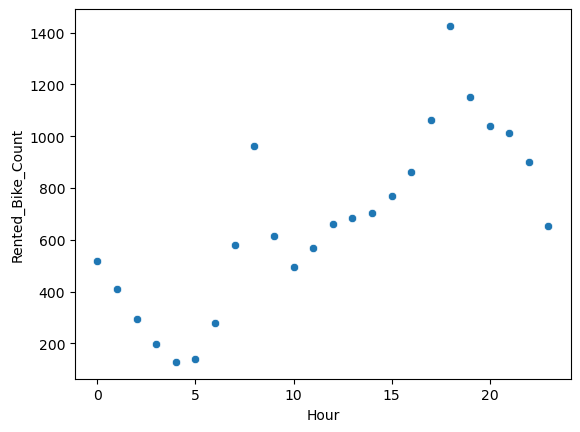

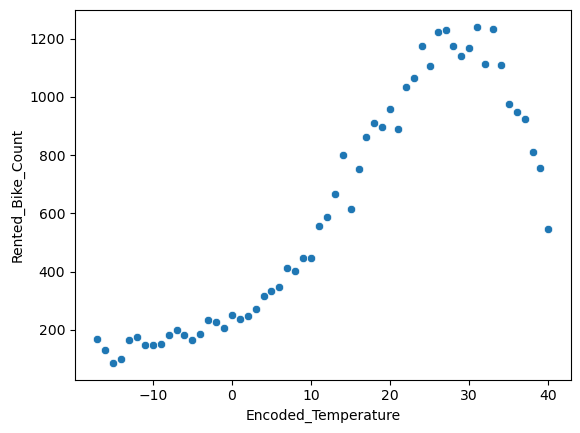

,Id,Date,Rented_Bike_Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Holiday,Functioning Day,Demand,Encoded_Hour,Encoded_Temperature
0,0,01/12/2017,254.0,0,-5.2,37,2.2,4,-17.6,0.00,0.0,0.0,No Holiday,Yes,0,517.933824,165.202899
1,1,01/12/2017,204.0,1,-5.5,38,0.8,4,-17.6,0.00,0.0,0.0,No Holiday,Yes,0,409.400735,165.202899
2,2,01/12/2017,173.0,2,-6.0,39,1.0,4,-17.7,0.00,0.0,0.0,No Holiday,Yes,0,293.738971,182.725000
3,3,01/12/2017,107.0,3,-6.2,40,0.9,4,-17.6,0.00,0.0,0.0,No Holiday,Yes,0,197.397059,182.725000
4,4,01/12/2017,78.0,4,-6.0,36,2.3,4,-18.6,0.00,0.0,0.0,No Holiday,Yes,0,128.213235,182.725000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6571,6571,31/08/2018,2372.0,19,26.5,69,2.3,4,20.3,0.18,0.0,0.0,No Holiday,Yes,1,1152.455882,1228.646707
6572,6572,31/08/2018,1995.0,20,25.4,74,1.6,4,20.4,0.00,0.0,0.0,No Holiday,Yes,1,1040.860294,1223.677632
6573,6573,31/08/2018,1931.0,21,24.5,78,1.2,4,20.4,0.00,0.0,0.0,No Holiday,Yes,1,1010.735294,1107.287037
6574,6574,31/08/2018,1789.0,22,24.1,80,0.9,4,20.4,0.00,0.0,0.0,No Holiday,Yes,1,901.742647,1107.287037


In [106]:
df
mean = df.groupby('Hour')['Rented_Bike_Count'].mean()
#count = df.groupby('Hour')['Rented_Bike_Count'].count()
a0 = df.groupby('Hour')['Rented_Bike_Count'].mean()
df['Encoded_Hour'] = df['Hour'].map(mean)
#df['Hour'].unique()
sns.scatterplot(data = mean)
plt.show()
plt.close()
def ceil(a):
    if(a > (a//1)):
        return (a//1) + 1
    else:
        return (a)

df['Temperature(°C)'].describe()
df['Encoded_Temperature'] = df['Temperature(°C)'].apply(ceil)

mean = df.groupby('Encoded_Temperature')['Rented_Bike_Count'].mean()
a1 = mean
df['Encoded_Temperature'] = df['Encoded_Temperature'].map(mean)
#count = df.groupby('Encoded_Temperature')['Rented_Bike_Count'].count() < 50
#count.value_counts()
def vis(a):
    if(a > 1500):
        return 4
    elif(a > 1000):
        return 3
    elif(a > 500):
        return 2
    else:
        return 1


df['Visibility (10m)'] = df['Visibility (10m)'].apply(vis)
a2 = df['Visibility (10m)']

sns.scatterplot(data = mean)

plt.show()
plt.close()# df['Humidity(%)'] = (df['Humidity(%)']) / 100    ####CHECK THIS OUT
# df['Humidity(%)']

df.describe()
df


In [107]:
df.dtypes

Id                             int64
Date                          object
Rented_Bike_Count            float64
Hour                           int64
Temperature(°C)              float64
Humidity(%)                    int64
Wind speed (m/s)             float64
Visibility (10m)               int64
Dew point temperature(°C)    float64
Solar Radiation (MJ/m2)      float64
Rainfall(mm)                 float64
Snowfall (cm)                float64
Holiday                       object
Functioning Day               object
Demand                         int64
Encoded_Hour                 float64
Encoded_Temperature          float64
dtype: object

<Axes: xlabel='Dew_Temperature_Encoded', ylabel='Rented_Bike_Count'>

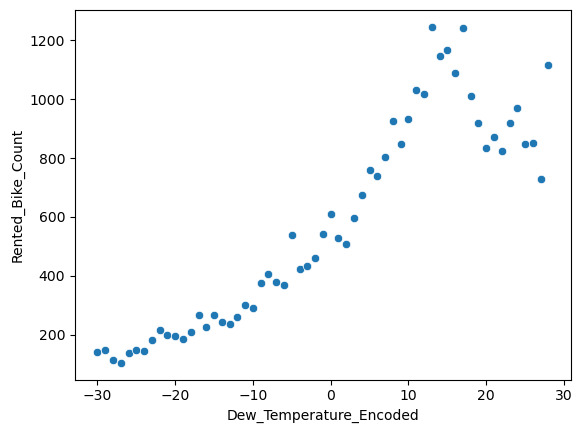

In [108]:
df['Dew_Temperature_Encoded'] = df['Dew point temperature(°C)'].apply(ceil)

mean = df.groupby('Dew_Temperature_Encoded')['Rented_Bike_Count'].mean()
a3 = mean
df['Dew_Temperature_Encoded'] = df['Dew_Temperature_Encoded'].map(mean)
mean
sns.scatterplot(data = mean)

In [109]:
# d = {
#     'Summer' : 3,
#     'Winter' : 1,
#     'Spring' : 2
# }
# df['Seasons'] = df['Seasons'].map(d)
# mean = df.groupby('Seasons')['Rented_Bike_Count'].mean()
# a4 = mean
# df['Seasons'] = df['Seasons'].map(mean)
# mean
# df
# sns.scatterplot(data = mean,linestyle = '-', markers='o')
# plt.tight_layout()
# plt.show()
# plt.close()


In [110]:
d = {
    'No Holiday' : 0,
    'Yes' : 1,
    'No' : 0,
    'Holiday':1   
}

df['Holiday'] = df['Holiday'].map(d)
df['Functioning Day'] = df['Functioning Day'].map(d)
df = df.drop(columns=['Demand'])
df

,Id,Date,Rented_Bike_Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Holiday,Functioning Day,Encoded_Hour,Encoded_Temperature,Dew_Temperature_Encoded
0,0,01/12/2017,254.0,0,-5.2,37,2.2,4,-17.6,0.00,0.0,0.0,0,1,517.933824,165.202899,266.577320
1,1,01/12/2017,204.0,1,-5.5,38,0.8,4,-17.6,0.00,0.0,0.0,0,1,409.400735,165.202899,266.577320
2,2,01/12/2017,173.0,2,-6.0,39,1.0,4,-17.7,0.00,0.0,0.0,0,1,293.738971,182.725000,266.577320
3,3,01/12/2017,107.0,3,-6.2,40,0.9,4,-17.6,0.00,0.0,0.0,0,1,197.397059,182.725000,266.577320
4,4,01/12/2017,78.0,4,-6.0,36,2.3,4,-18.6,0.00,0.0,0.0,0,1,128.213235,182.725000,210.203704
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6571,6571,31/08/2018,2372.0,19,26.5,69,2.3,4,20.3,0.18,0.0,0.0,0,1,1152.455882,1228.646707,870.811321
6572,6572,31/08/2018,1995.0,20,25.4,74,1.6,4,20.4,0.00,0.0,0.0,0,1,1040.860294,1223.677632,870.811321
6573,6573,31/08/2018,1931.0,21,24.5,78,1.2,4,20.4,0.00,0.0,0.0,0,1,1010.735294,1107.287037,870.811321
6574,6574,31/08/2018,1789.0,22,24.1,80,0.9,4,20.4,0.00,0.0,0.0,0,1,901.742647,1107.287037,870.811321


In [111]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer

X_train = df
scaler = StandardScaler()
X_train['Humidity(%)'] = scaler.fit_transform(X_train[['Humidity(%)']])
scaler2 = MinMaxScaler(feature_range=(0,1))
scaler3 = RobustScaler()
scaler4 = PowerTransformer(method='yeo-johnson')
scaler5 = PowerTransformer(method='yeo-johnson')
scaler6 = PowerTransformer(method='yeo-johnson')
scaler7 = MinMaxScaler(feature_range=(0,1))
scaler8 = MinMaxScaler(feature_range=(0,1))
X_train['Encoded_Temperature'] = scaler4.fit_transform(X_train[['Encoded_Temperature']])
X_train['Dew_Temperature_Encoded'] = scaler5.fit_transform(X_train[['Dew_Temperature_Encoded']])
X_train['Encoded_Hour'] = scaler6.fit_transform(X_train[['Encoded_Hour']])
#X_train['Seasons'] = scaler2.fit_transform(X_train[['Seasons']])
X_train['Visibility (10m)'] = scaler7.fit_transform(X_train[['Visibility (10m)']])
df['Temperature(°C)'] = df['Temperature(°C)'].apply(ceil)
df['Dew point temperature(°C)'] = df['Dew point temperature(°C)'].apply(ceil)
# sns.scatterplot(data = X_train, x='Temperature(°C)', y= 'Encoded_Temperature')
# plt.tight_layout()
# plt.show()
# plt.close()
# sns.scatterplot(data = X_train, x='Dew point temperature(°C)', y= 'Dew_Temperature_Encoded')
# plt.tight_layout()
# plt.show()
# plt.close()
# sns.scatterplot(data = X_train, y='Encoded_Hour', x= 'Hour')
# plt.tight_layout()
# plt.show()
# plt.close()
# sns.kdeplot(data=X_train, x = 'Humidity(%)')




In [112]:
#sns.kdeplot(data=X_train, x = 'Dew_Temperature_Encoded')

df

,Id,Date,Rented_Bike_Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Holiday,Functioning Day,Encoded_Hour,Encoded_Temperature,Dew_Temperature_Encoded
0,0,01/12/2017,254.0,0,-5.0,-0.999959,2.2,1.0,-17.0,0.00,0.0,0.0,0,1,-0.386082,-1.441281,-1.272222
1,1,01/12/2017,204.0,1,-5.0,-0.952070,0.8,1.0,-17.0,0.00,0.0,0.0,0,1,-0.739419,-1.441281,-1.272222
2,2,01/12/2017,173.0,2,-6.0,-0.904181,1.0,1.0,-17.0,0.00,0.0,0.0,0,1,-1.147734,-1.353795,-1.272222
3,3,01/12/2017,107.0,3,-6.0,-0.856293,0.9,1.0,-17.0,0.00,0.0,0.0,0,1,-1.525331,-1.353795,-1.272222
4,4,01/12/2017,78.0,4,-6.0,-1.047848,2.3,1.0,-18.0,0.00,0.0,0.0,0,1,-1.830801,-1.353795,-1.499225
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6571,6571,31/08/2018,2372.0,19,27.0,0.532485,2.3,1.0,21.0,0.18,0.0,0.0,0,1,1.370737,1.251024,0.646704
6572,6572,31/08/2018,1995.0,20,26.0,0.771929,1.6,1.0,21.0,0.00,0.0,0.0,0,1,1.087875,1.242950,0.646704
6573,6573,31/08/2018,1931.0,21,25.0,0.963485,1.2,1.0,21.0,0.00,0.0,0.0,0,1,1.010035,1.048160,0.646704
6574,6574,31/08/2018,1789.0,22,25.0,1.059263,0.9,1.0,21.0,0.00,0.0,0.0,0,1,0.722558,1.048160,0.646704


In [113]:
X_train.drop(columns=['Temperature(°C)', 'Dew point temperature(°C)'], inplace= True)
X_train

,Id,Date,Rented_Bike_Count,Hour,Humidity(%),Wind speed (m/s),Visibility (10m),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Holiday,Functioning Day,Encoded_Hour,Encoded_Temperature,Dew_Temperature_Encoded
0,0,01/12/2017,254.0,0,-0.999959,2.2,1.0,0.00,0.0,0.0,0,1,-0.386082,-1.441281,-1.272222
1,1,01/12/2017,204.0,1,-0.952070,0.8,1.0,0.00,0.0,0.0,0,1,-0.739419,-1.441281,-1.272222
2,2,01/12/2017,173.0,2,-0.904181,1.0,1.0,0.00,0.0,0.0,0,1,-1.147734,-1.353795,-1.272222
3,3,01/12/2017,107.0,3,-0.856293,0.9,1.0,0.00,0.0,0.0,0,1,-1.525331,-1.353795,-1.272222
4,4,01/12/2017,78.0,4,-1.047848,2.3,1.0,0.00,0.0,0.0,0,1,-1.830801,-1.353795,-1.499225
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6571,6571,31/08/2018,2372.0,19,0.532485,2.3,1.0,0.18,0.0,0.0,0,1,1.370737,1.251024,0.646704
6572,6572,31/08/2018,1995.0,20,0.771929,1.6,1.0,0.00,0.0,0.0,0,1,1.087875,1.242950,0.646704
6573,6573,31/08/2018,1931.0,21,0.963485,1.2,1.0,0.00,0.0,0.0,0,1,1.010035,1.048160,0.646704
6574,6574,31/08/2018,1789.0,22,1.059263,0.9,1.0,0.00,0.0,0.0,0,1,0.722558,1.048160,0.646704


In [114]:
X_train['Date'] = pd.to_datetime(X_train['Date'], format="%d/%m/%Y")

# X_train['Day'] = X_train['Date'].dt.day
# X_train['Month'] = X_train['Date'].dt.month
# X_train['Year'] = X_train['Date'].dt.year
X_train['DOW'] = X_train['Date'].dt.day_of_week

# mean1 = df.groupby('Day')['Rented_Bike_Count'].mean()
# mean2 = df.groupby('Month')['Rented_Bike_Count'].mean()
# mean3 = df.groupby('Year')['Rented_Bike_Count'].mean()
mean4 = df.groupby('DOW')['Rented_Bike_Count'].mean()

X_train['DOW'] = X_train['DOW'].map(mean4)
X_train['DOW'] = scaler8.fit_transform(X_train[['DOW']])

# sns.scatterplot(data = X_train, y='Rented_Bike_Count', x= 'Day')
# plt.tight_layout()
# plt.show()
# plt.close()
# sns.scatterplot(data = X_train, y='Rented_Bike_Count', x= 'Month')
# plt.tight_layout()
# plt.show()
# plt.close()
# sns.scatterplot(data = X_train, y='Rented_Bike_Count', x= 'Year')
# plt.tight_layout()
# plt.show()
# plt.close()
# sns.scatterplot(data = X_train, y='Rented_Bike_Count', x= 'DOW', alpha= 0.05)
# plt.tight_layout()
# plt.show()
# plt.close()


In [115]:
X_train.drop(columns=['Date', 'Id','Functioning Day'], inplace= True)#Check this

In [116]:
#########################################################################################################

In [117]:
df2 = pd.read_csv('test.csv')





df2.drop(columns=['Seasons'], inplace = True)

mean = a0

df2['Encoded_Hour'] = df2['Hour'].map(mean)

df2['Encoded_Temperature'] = df2['Temperature(°C)'].apply(ceil)
mean = a1
df2['Encoded_Temperature'] = df2['Encoded_Temperature'].map(a1)




df2['Visibility (10m)'] = df2['Visibility (10m)'].apply(vis)





df2['Dew_Temperature_Encoded'] = df2['Dew point temperature(°C)'].apply(ceil)

mean = a3
df2['Dew_Temperature_Encoded'] = df2['Dew_Temperature_Encoded'].map(mean)







# df2['Seasons'] = df2['Seasons'].map(d)
# mean = a4
# df2['Seasons'] = df2['Seasons'].map(mean)








df2['Holiday'] = df2['Holiday'].map(d)
df2['Functioning Day'] = df2['Functioning Day'].map(d)






In [118]:
X_test = df2.copy()

X_test['Humidity(%)'] = scaler.transform(X_test[['Humidity(%)']])

X_test['Encoded_Temperature'] = scaler4.transform(X_test[['Encoded_Temperature']])
X_test['Dew_Temperature_Encoded'] = scaler5.transform(X_test[['Dew_Temperature_Encoded']])
X_test['Encoded_Hour'] = scaler6.transform(X_test[['Encoded_Hour']])
#X_test['Seasons'] = scaler2.transform(X_test[['Seasons']])
X_test['Visibility (10m)'] = scaler7.transform(X_test[['Visibility (10m)']])





X_test.drop(columns=['Temperature(°C)', 'Dew point temperature(°C)'], inplace= True)








X_test['Date'] = pd.to_datetime(X_test['Date'], format="%d/%m/%Y")

X_test['DOW'] = X_test['Date'].dt.day_of_week

X_test['DOW'] = X_test['DOW'].map(mean4)
X_test['DOW'] = scaler8.transform(X_test[['DOW']])




test_data_id = X_test['Id']

X_test.drop(columns=['Date', 'Id', 'Functioning Day' ], inplace= True) #CHECK THIS



In [119]:
#X_test['Seasons'].isna().value_counts()
#test_data_id


In [120]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
y_train = np.log1p(X_train['Rented_Bike_Count'])#Check this 
X_train = X_train.drop(columns=['Rented_Bike_Count'])
lr = LinearRegression().fit(X_train, y_train)

lr.score(X_train, y_train)


from sklearn.metrics import root_mean_squared_error

val_predictions = lr.predict(X_train)

# Calculate and print the Root Mean Squared Error (RMSE)
val_rmse = root_mean_squared_error(y_train, (val_predictions))
print(f"Local Validation RMSE: {val_rmse:.4f}")

Local Validation RMSE: 0.6264


In [121]:
lasso = Lasso(alpha= 0.1)
lasso.fit(X_train, y_train)

print(lasso.score(X_train, y_train))



val_predictions = lasso.predict(X_train)

# Calculate and print the Root Mean Squared Error (RMSE)
val_rmse = root_mean_squared_error(y_train, val_predictions)
print(f"Local Validation RMSE: {val_rmse:.4f}")
print(lasso.coef_)
print(lasso.feature_names_in_)


0.660515654345414
Local Validation RMSE: 0.6842
[ 0.01011036 -0.18445729 -0.          0.          0.         -0.17287851
 -0.         -0.          0.32260464  0.63587478  0.          0.        ]
['Hour' 'Humidity(%)' 'Wind speed (m/s)' 'Visibility (10m)'
 'Solar Radiation (MJ/m2)' 'Rainfall(mm)' 'Snowfall (cm)' 'Holiday'
 'Encoded_Hour' 'Encoded_Temperature' 'Dew_Temperature_Encoded' 'DOW']


In [122]:
ridge = Ridge(alpha= 0.001)
ridge.fit(X_train, y_train)

print(ridge.score(X_train, y_train))



val_predictions = ridge.predict(X_train)

# Calculate and print the Root Mean Squared Error (RMSE)
val_rmse = root_mean_squared_error(y_train, val_predictions)
print(f"Local Validation RMSE: {val_rmse:.4f}")


0.7155303279929
Local Validation RMSE: 0.6264


,Id,Rented_Bike_Count
count,2184.000000,2184.000000
mean,7667.500000,6.153228
std,630.610815,0.873164
min,6576.000000,1.687019
25%,7121.750000,5.580005
50%,7667.500000,6.204785
75%,8213.250000,6.795633
max,8759.000000,8.375228


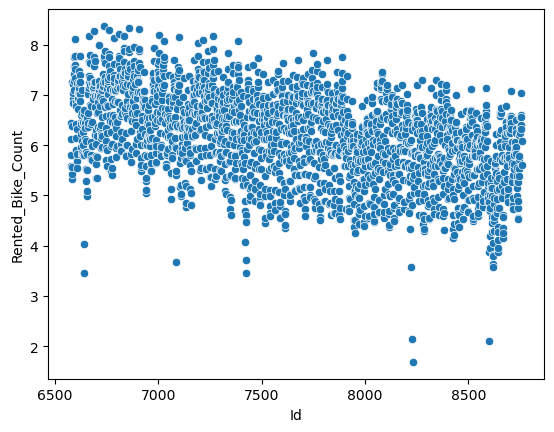

In [123]:
test_predictions = lr.predict(X_test)

# Create the submission dataframe
submission = pd.DataFrame({
    'Id': test_data_id,
    'Rented_Bike_Count': test_predictions
})

# Display the first few rows of the submission
display(submission.describe())
sns.scatterplot(data = submission, x = 'Id', y = 'Rented_Bike_Count')
plt.show()
plt.close()


submission.iloc[submission[df2['Functioning Day'] == 0].index, 1] = 0
# Export to CSV (without the pandas index)
submission.to_csv('submission2.csv', index=False)

In [124]:
display(submission.describe())
(submission['Rented_Bike_Count'] >= 0).value_counts()

,Id,Rented_Bike_Count
count,2184.000000,2184.000000
mean,7667.500000,5.434253
std,630.610815,2.106427
min,6576.000000,0.000000
25%,7121.750000,5.175720
50%,7667.500000,6.019486
75%,8213.250000,6.679390
max,8759.000000,8.375228


Rented_Bike_Count
True    2184
Name: count, dtype: int64

Local Validation RMSE: 2.1583


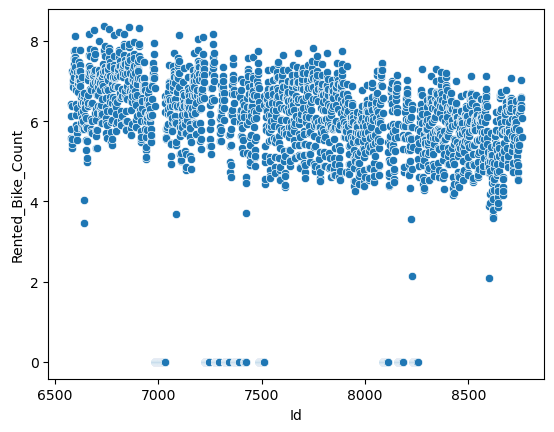

In [125]:

submission.describe()
sns.scatterplot(data = submission, x = 'Id', y = 'Rented_Bike_Count')
val_rmse = root_mean_squared_error(test_predictions, submission['Rented_Bike_Count'])
print(f"Local Validation RMSE: {val_rmse:.4f}")

In [126]:
X_train

,Hour,Humidity(%),Wind speed (m/s),Visibility (10m),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Holiday,Encoded_Hour,Encoded_Temperature,Dew_Temperature_Encoded,DOW
0,0,-0.999959,2.2,1.0,0.00,0.0,0.0,0,-0.386082,-1.441281,-1.272222,1.0
1,1,-0.952070,0.8,1.0,0.00,0.0,0.0,0,-0.739419,-1.441281,-1.272222,1.0
2,2,-0.904181,1.0,1.0,0.00,0.0,0.0,0,-1.147734,-1.353795,-1.272222,1.0
3,3,-0.856293,0.9,1.0,0.00,0.0,0.0,0,-1.525331,-1.353795,-1.272222,1.0
4,4,-1.047848,2.3,1.0,0.00,0.0,0.0,0,-1.830801,-1.353795,-1.499225,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
6571,19,0.532485,2.3,1.0,0.18,0.0,0.0,0,1.370737,1.251024,0.646704,1.0
6572,20,0.771929,1.6,1.0,0.00,0.0,0.0,0,1.087875,1.242950,0.646704,1.0
6573,21,0.963485,1.2,1.0,0.00,0.0,0.0,0,1.010035,1.048160,0.646704,1.0
6574,22,1.059263,0.9,1.0,0.00,0.0,0.0,0,0.722558,1.048160,0.646704,1.0


In [128]:
df2['Rented_Bike_Count'] = submission['Rented_Bike_Count']
df2

,Id,Date,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Holiday,Functioning Day,Encoded_Hour,Encoded_Temperature,Dew_Temperature_Encoded,Rented_Bike_Count
0,6576,01/09/2018,0,23.2,83,0.5,4,20.1,0.0,0.0,0.0,0,1,517.933824,1174.054187,870.811321,6.435537
1,6577,01/09/2018,1,22.7,83,0.1,4,19.6,0.0,0.0,0.0,0,1,409.400735,1063.562189,835.434146,6.127125
2,6578,01/09/2018,2,22.0,86,0.4,4,19.5,0.0,0.0,0.0,0,1,293.738971,1033.031746,835.434146,5.802815
3,6579,01/09/2018,3,21.6,87,0.3,4,19.3,0.0,0.0,0.0,0,1,197.397059,1033.031746,835.434146,5.578885
4,6580,01/09/2018,4,21.2,88,0.9,3,19.1,0.0,0.0,0.0,0,1,128.213235,1033.031746,835.434146,5.334482
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2179,8755,30/11/2018,19,4.2,34,2.6,4,-10.3,0.0,0.0,0.0,0,1,1152.455882,333.849315,290.935065,6.570977
2180,8756,30/11/2018,20,3.4,37,2.3,4,-9.9,0.0,0.0,0.0,0,1,1040.860294,314.880000,375.011236,6.398251
2181,8757,30/11/2018,21,2.6,39,0.3,4,-9.9,0.0,0.0,0.0,0,1,1010.735294,272.502762,375.011236,6.321751
2182,8758,30/11/2018,22,2.1,41,1.0,4,-9.8,0.0,0.0,0.0,0,1,901.742647,272.502762,375.011236,6.088640


<Axes: xlabel='Hour', ylabel='Rented_Bike_Count'>

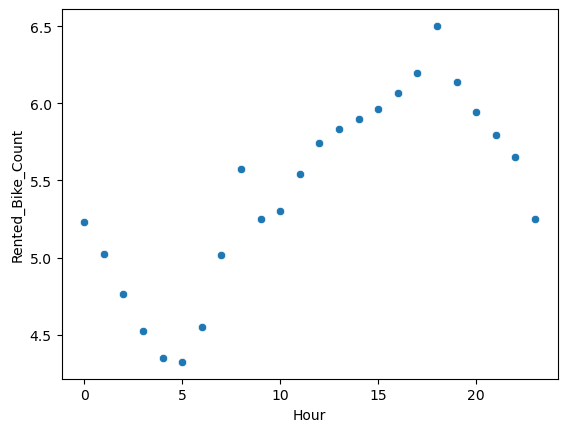

In [ ]:

# sns.scatterplot(data = df2, x='Encoded_Temperature', y = 'Rented_Bike_Count')
# plt.show()
# plt.close()
# sns.scatterplot(data = df2, x= 'Encoded_Hour', y = 'Rented_Bike_Count')
# plt.show()
# plt.close()
# df2['Hour'] = df2['Hour'].apply(ceil)

# mean = df2.groupby('Hour')['Rented_Bike_Count'].mean()

# sns.scatterplot(data = mean)